# Coffee Sales

## P1: Sales Trends & Customer Behavior
- Objective: Understand sales patterns (time-based, product-based, and customer-based).

  - Charts/Visuals (Pastel Palette):
    - Monthly sales trend (line chart).
    - Revenue by product type (bar chart).
    - Sales distribution by payment type (pie/donut chart).
    - Hourly sales pattern (bar chart).
    - Weekly sales comparison (bar chart).
    - Top 5 customers by total purchase (horizontal bar).
  - ML Models:
    - Features: day, hour, product type, payment type.
    - Linear Regression – Predict daily sales revenue.
    - Evaluation: RMSE, R².
    - Random Forest Regressor – Same prediction, with feature importance to interpret drivers of sales.

In [14]:
# ============================
# P1: Sales Trends & Customer Behavior
# ============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set pastel theme
sns.set_theme(style="whitegrid", palette="pastel")

In [15]:
# ============================
# Load Dataset
# ============================
df = pd.read_csv("index.csv")

# Preview
print("Shape:", df.shape)
df.head()

Shape: (1133, 6)


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [16]:
# ============================
# Data Cleaning
# ============================
# Convert datetime columns
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Handle missing values
df['card'] = df['card'].fillna("CASH_USER")

# Drop duplicates if any
df = df.drop_duplicates()

# Feature Engineering
df['month'] = df['date'].dt.to_period('M')
df['day'] = df['date'].dt.day_name()
df['hour'] = df['datetime'].dt.hour

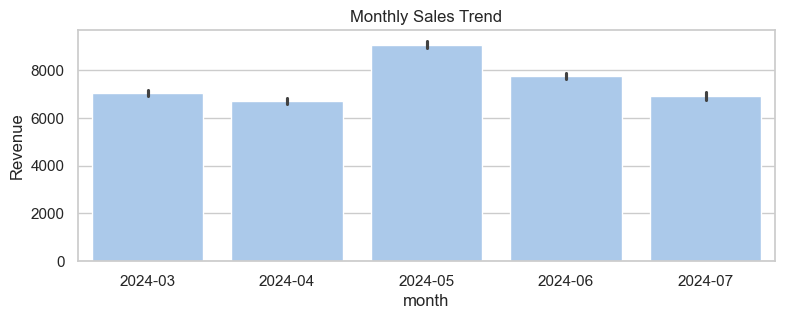

In [17]:
# ============================
# Exploratory Data Analysis
# ============================

# 1. Monthly Sales Trend
monthly_sales = df.groupby('month')['money'].sum()
plt.figure(figsize=(9,3))
sns.barplot(data=df, x="month", y="money", estimator=sum)
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

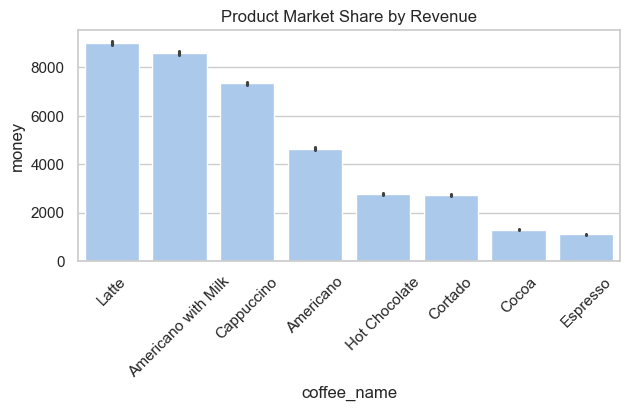

In [18]:
# 2. Revenue by Product
plt.figure(figsize=(7,3))
sns.barplot(data=df, x="coffee_name", y="money", estimator=sum, order=df.groupby("coffee_name")["money"].sum().sort_values(ascending=False).index)
plt.title("Product Market Share by Revenue")
plt.xticks(rotation=45)
plt.show()

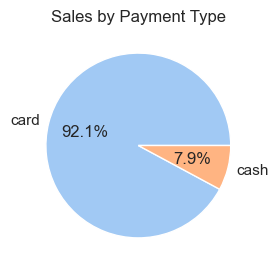

In [10]:
# 3. Sales by Payment Type
plt.figure(figsize=(5,3))
df['cash_type'].value_counts().plot.pie(autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Sales by Payment Type")
plt.ylabel("")
plt.show()

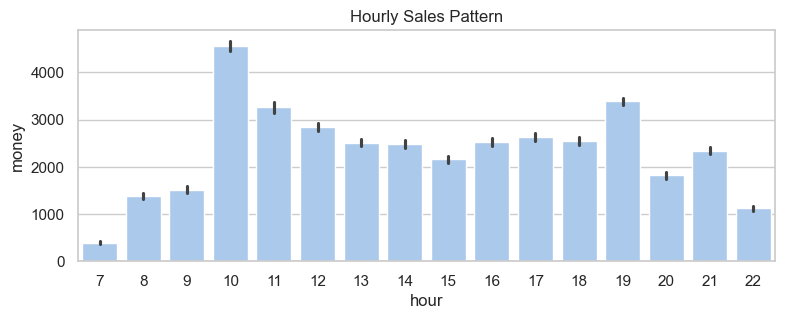

In [12]:
# 4. Hourly Sales
plt.figure(figsize=(9,3))
sns.barplot(data=df, x="hour", y="money", estimator=sum)
plt.title("Hourly Sales Pattern")
plt.show()

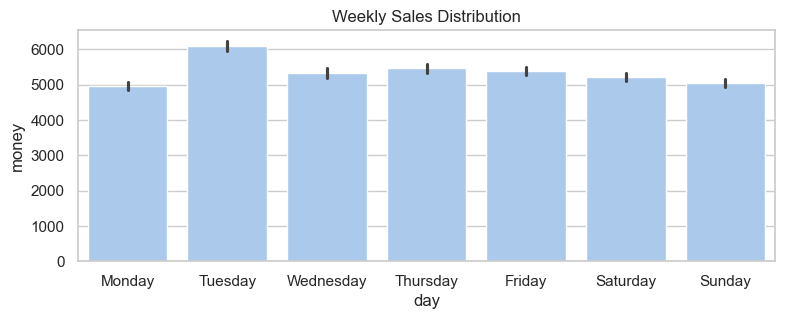

In [12]:
# 5. Weekly Sales Distribution
plt.figure(figsize=(9,3))
sns.barplot(data=df, x="day", y="money", estimator=sum,
            order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Weekly Sales Distribution")
plt.xticks(rotation=0)
plt.show()

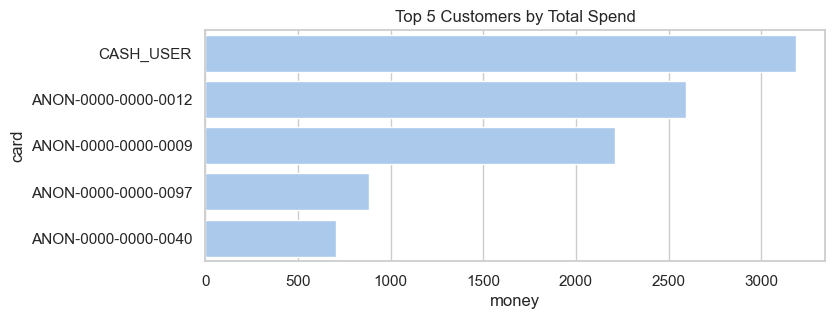

In [17]:
# 6. Top 5 Customers
top_customers = df.groupby("card")["money"].sum().nlargest(5).reset_index()
plt.figure(figsize=(8,3))
sns.barplot(data=top_customers, x="money", y="card")
plt.title("Top 5 Customers by Total Spend")
plt.show()

In [18]:
# ============================
# Machine Learning Models
# ============================

# Prepare features
X = df[['hour','money']].copy()
X['day_num'] = df['datetime'].dt.weekday  # Monday=0
X['is_card'] = (df['cash_type']=="card").astype(int)
X = X.drop(columns=['money'])  # Drop target leakage

y = df['money']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Feature Importance
importances = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)
print("\nFeature Importances:\n", importances)


Feature Importances:
    Feature  Importance
0     hour    0.511730
1  day_num    0.399491
2  is_card    0.088779


In [20]:
# ---- Model 1: Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MSE: 18.039256774099496
R²: 0.031005633617324335


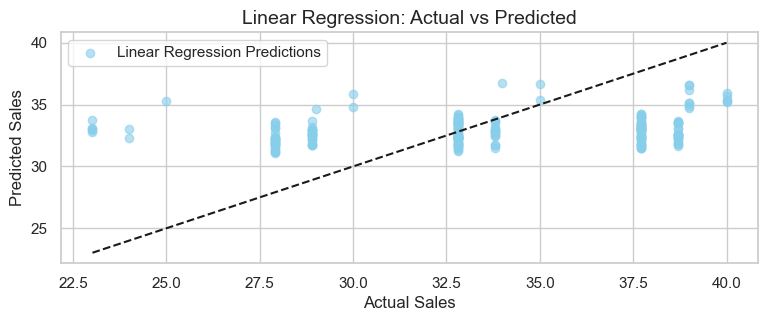

In [24]:
plt.figure(figsize=(9,3))
plt.scatter(y_test, y_pred_lr, color="#87CEEB", alpha=0.6, label="Linear Regression Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.title("Linear Regression: Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.show()

In [21]:
# ---- Model 2: Random Forest ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest Performance:
MSE: 21.370973192475446
R²: -0.1479604113932591


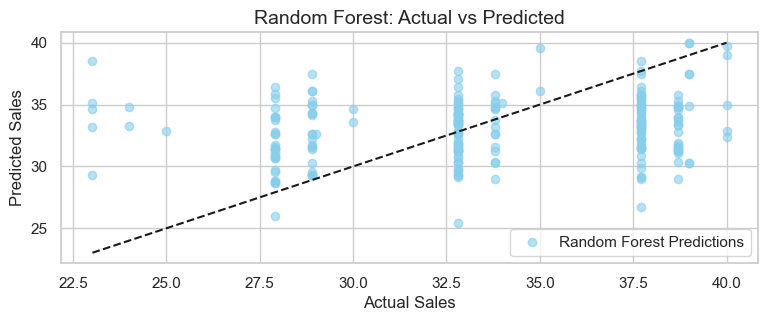

In [27]:
plt.figure(figsize=(9,3))
plt.scatter(y_test, y_pred_rf, color="#87CEEB", alpha=0.6, label="Random Forest Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.title("Random Forest: Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.show()

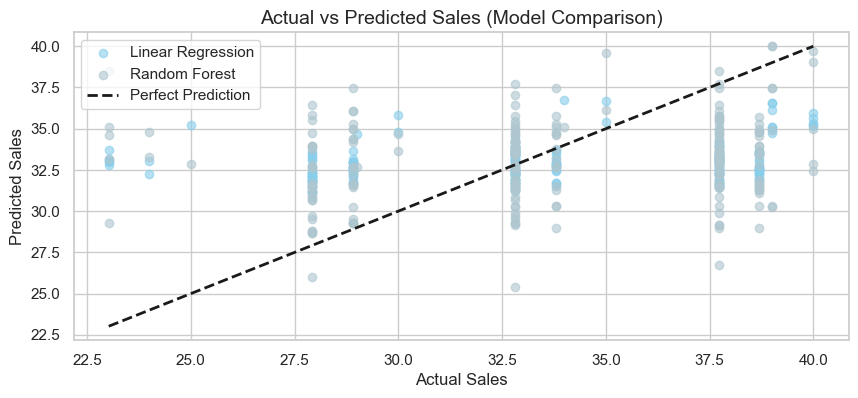

In [30]:
# ============================
# Visualizing Model Predictions
# ============================

plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred_lr, color="#87CEEB", alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_rf, color="#AEC6CF", alpha=0.6, label="Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'k--', lw=2, label="Perfect Prediction")
plt.title("Actual vs Predicted Sales (Model Comparison)", fontsize=14)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.show()